# 01 - Exploratory Data Analysis

Explore the brain tumor MRI dataset, check class balance, inspect image properties, and look for data quality issues before preprocessing and model training.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image, ImageFile
import matplotlib.pyplot as plt
import seaborn as sns

ImageFile.LOAD_TRUNCATED_IMAGES = True
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titleweight'] = 'bold'


In [ ]:
from __future__ import annotations
from pathlib import Path

def find_project_root(start: Path | None = None) -> Path:
    start = start or Path.cwd()
    for candidate in [start, *start.parents]:
        if (candidate / 'data' / 'raw' / 'Training').exists() and (candidate / 'data' / 'raw' / 'Testing').exists():
            return candidate
    raise FileNotFoundError('Could not locate data/raw/Training and data/raw/Testing.')

PROJECT_ROOT = find_project_root()
TRAIN_DIR = PROJECT_ROOT / 'data' / 'raw' / 'Training'
TEST_DIR = PROJECT_ROOT / 'data' / 'raw' / 'Testing'
CLASSES = ['glioma', 'meningioma', 'notumor', 'pituitary']
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'}
PROJECT_ROOT, TRAIN_DIR, TEST_DIR

(PosixPath('/Users/apple/Desktop/ml capstone/Brain Tumor Detection and Classification using Deep Learning with Explainable AI (Grad-CAM)'),
 PosixPath('/Users/apple/Desktop/ml capstone/Brain Tumor Detection and Classification using Deep Learning with Explainable AI (Grad-CAM)/data/raw/Training'),
 PosixPath('/Users/apple/Desktop/ml capstone/Brain Tumor Detection and Classification using Deep Learning with Explainable AI (Grad-CAM)/data/raw/Testing'))

In [9]:
def collect_image_files(root: Path) -> list[Path]:
    files: list[Path] = []
    for class_name in CLASSES:
        class_dir = root / class_name
        if class_dir.exists():
            files.extend(sorted(p for p in class_dir.rglob('*') if p.suffix.lower() in IMAGE_EXTENSIONS))
    return files

train_files = collect_image_files(TRAIN_DIR)
test_files = collect_image_files(TEST_DIR)

def build_file_table(files: list[Path], split_name: str) -> pd.DataFrame:
    rows = []
    for file_path in files:
        rows.append({
            'split': split_name,
            'class': file_path.parent.name,
            'file_name': file_path.name,
            'path': str(file_path),
            'extension': file_path.suffix.lower(),
        })
    return pd.DataFrame(rows)

dataset_df = pd.concat([
    build_file_table(train_files, 'training'),
    build_file_table(test_files, 'testing')
], ignore_index=True)
dataset_df.head()

,split,class,file_name,path,extension
0,training,glioma,Tr-gl_1.jpg,/Users/apple/Desktop/ml capstone/Brain Tumor D...,.jpg
1,training,glioma,Tr-gl_10.jpg,/Users/apple/Desktop/ml capstone/Brain Tumor D...,.jpg
2,training,glioma,Tr-gl_100.jpg,/Users/apple/Desktop/ml capstone/Brain Tumor D...,.jpg
3,training,glioma,Tr-gl_1000.jpg,/Users/apple/Desktop/ml capstone/Brain Tumor D...,.jpg
4,training,glioma,Tr-gl_1001.jpg,/Users/apple/Desktop/ml capstone/Brain Tumor D...,.jpg


In [10]:
summary = dataset_df.groupby(['split', 'class']).size().reset_index(name='count')
summary_pivot = summary.pivot(index='class', columns='split', values='count').fillna(0).astype(int)
summary_pivot.loc[CLASSES]

split,testing,training
class,,
glioma,400,1400
meningioma,400,1400
notumor,400,1400
pituitary,400,1400


/var/folders/gh/2f7t55xd4lx_76x21r934l340000gn/T/ipykernel_93735/2488159581.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=train_counts.index, y=train_counts.values, ax=axes[0], palette='viridis')
/var/folders/gh/2f7t55xd4lx_76x21r934l340000gn/T/ipykernel_93735/2488159581.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=test_counts.index, y=test_counts.values, ax=axes[1], palette='magma')


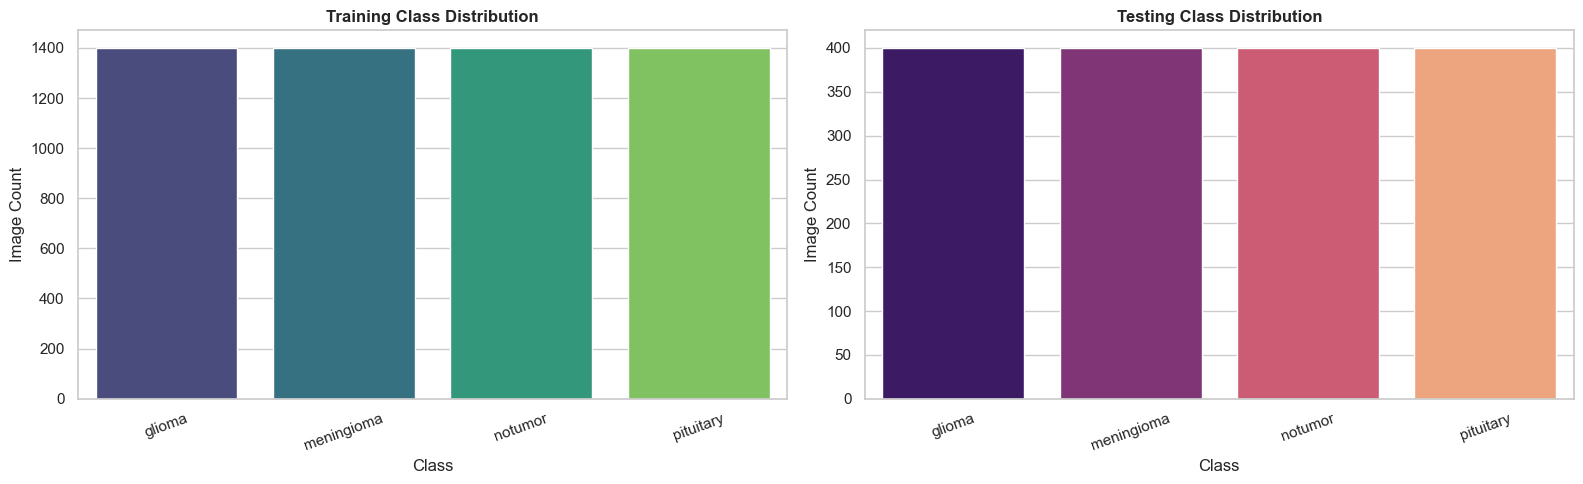

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
train_counts = dataset_df[dataset_df['split'] == 'training']['class'].value_counts().reindex(CLASSES)
test_counts = dataset_df[dataset_df['split'] == 'testing']['class'].value_counts().reindex(CLASSES)
sns.barplot(x=train_counts.index, y=train_counts.values, ax=axes[0], palette='viridis')
axes[0].set_title('Training Class Distribution')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Image Count')
sns.barplot(x=test_counts.index, y=test_counts.values, ax=axes[1], palette='magma')
axes[1].set_title('Testing Class Distribution')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Image Count')
for ax in axes:
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

In [12]:
image_records = []
corrupted_files = []
for file_path in dataset_df['path'].map(Path):
    try:
        with Image.open(file_path) as image:
            image.load()
            width, height = image.size
            image_records.append({
                'path': str(file_path),
                'class': file_path.parent.name,
                'split': file_path.parents[1].name,
                'width': width,
                'height': height,
                'channels': len(image.getbands()),
                'mode': image.mode,
                'aspect_ratio': round(width / height, 3),
            })
    except Exception:
        corrupted_files.append(str(file_path))
image_df = pd.DataFrame(image_records)
image_df.describe(include='all')

,path,class,split,width,height,channels,mode,aspect_ratio
count,7200,7200,7200,7200.000000,7200.000000,7200.000000,7200,7200.000000
unique,7200,4,2,NaN,NaN,NaN,4,NaN
top,/Users/apple/Desktop/ml capstone/Brain Tumor D...,glioma,Training,NaN,NaN,NaN,RGB,NaN
freq,1,1800,5600,NaN,NaN,NaN,4129,NaN
mean,NaN,NaN,NaN,453.302917,456.899167,2.148194,NaN,0.989716
std,NaN,NaN,NaN,130.048964,124.402496,0.989659,NaN,0.091661
min,NaN,NaN,NaN,150.000000,167.000000,1.000000,NaN,0.645000
25%,NaN,NaN,NaN,442.000000,449.000000,1.000000,NaN,1.000000
50%,NaN,NaN,NaN,512.000000,512.000000,3.000000,NaN,1.000000
75%,NaN,NaN,NaN,512.000000,512.000000,3.000000,NaN,1.000000


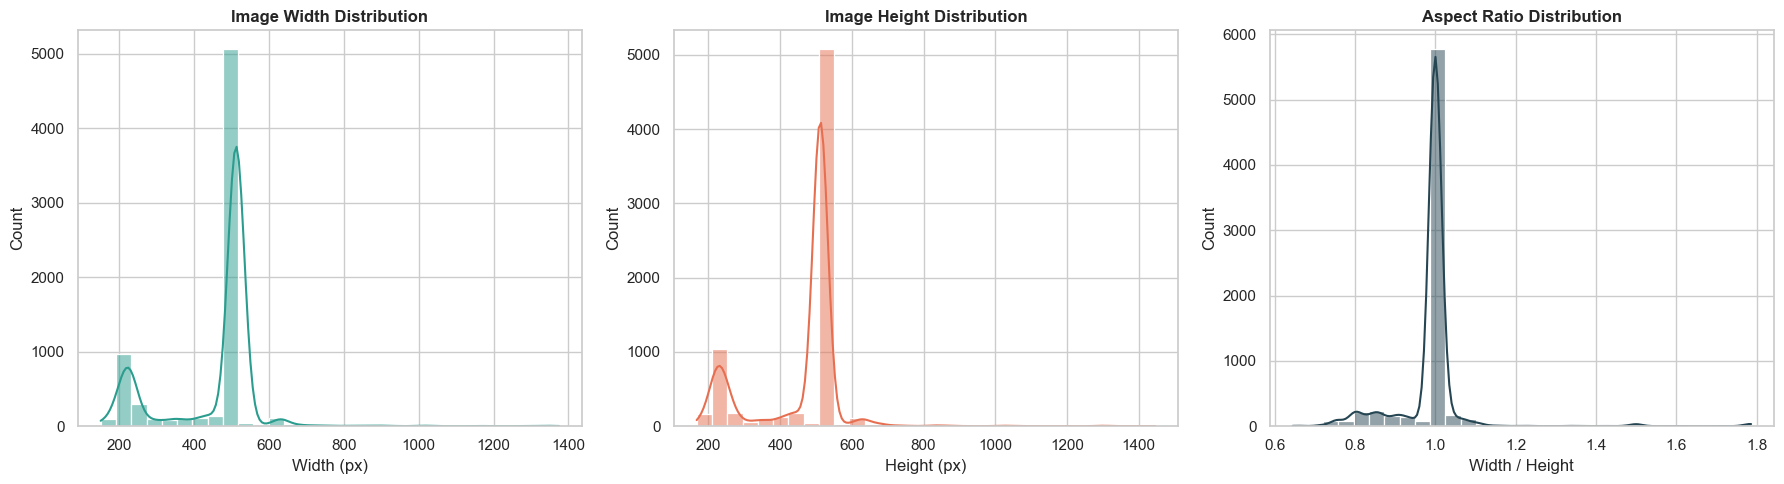

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(image_df['width'], bins=30, kde=True, ax=axes[0], color='#2a9d8f')
axes[0].set_title('Image Width Distribution')
axes[0].set_xlabel('Width (px)')
sns.histplot(image_df['height'], bins=30, kde=True, ax=axes[1], color='#e76f51')
axes[1].set_title('Image Height Distribution')
axes[1].set_xlabel('Height (px)')
sns.histplot(image_df['aspect_ratio'], bins=30, kde=True, ax=axes[2], color='#264653')
axes[2].set_title('Aspect Ratio Distribution')
axes[2].set_xlabel('Width / Height')
plt.tight_layout()
plt.show()

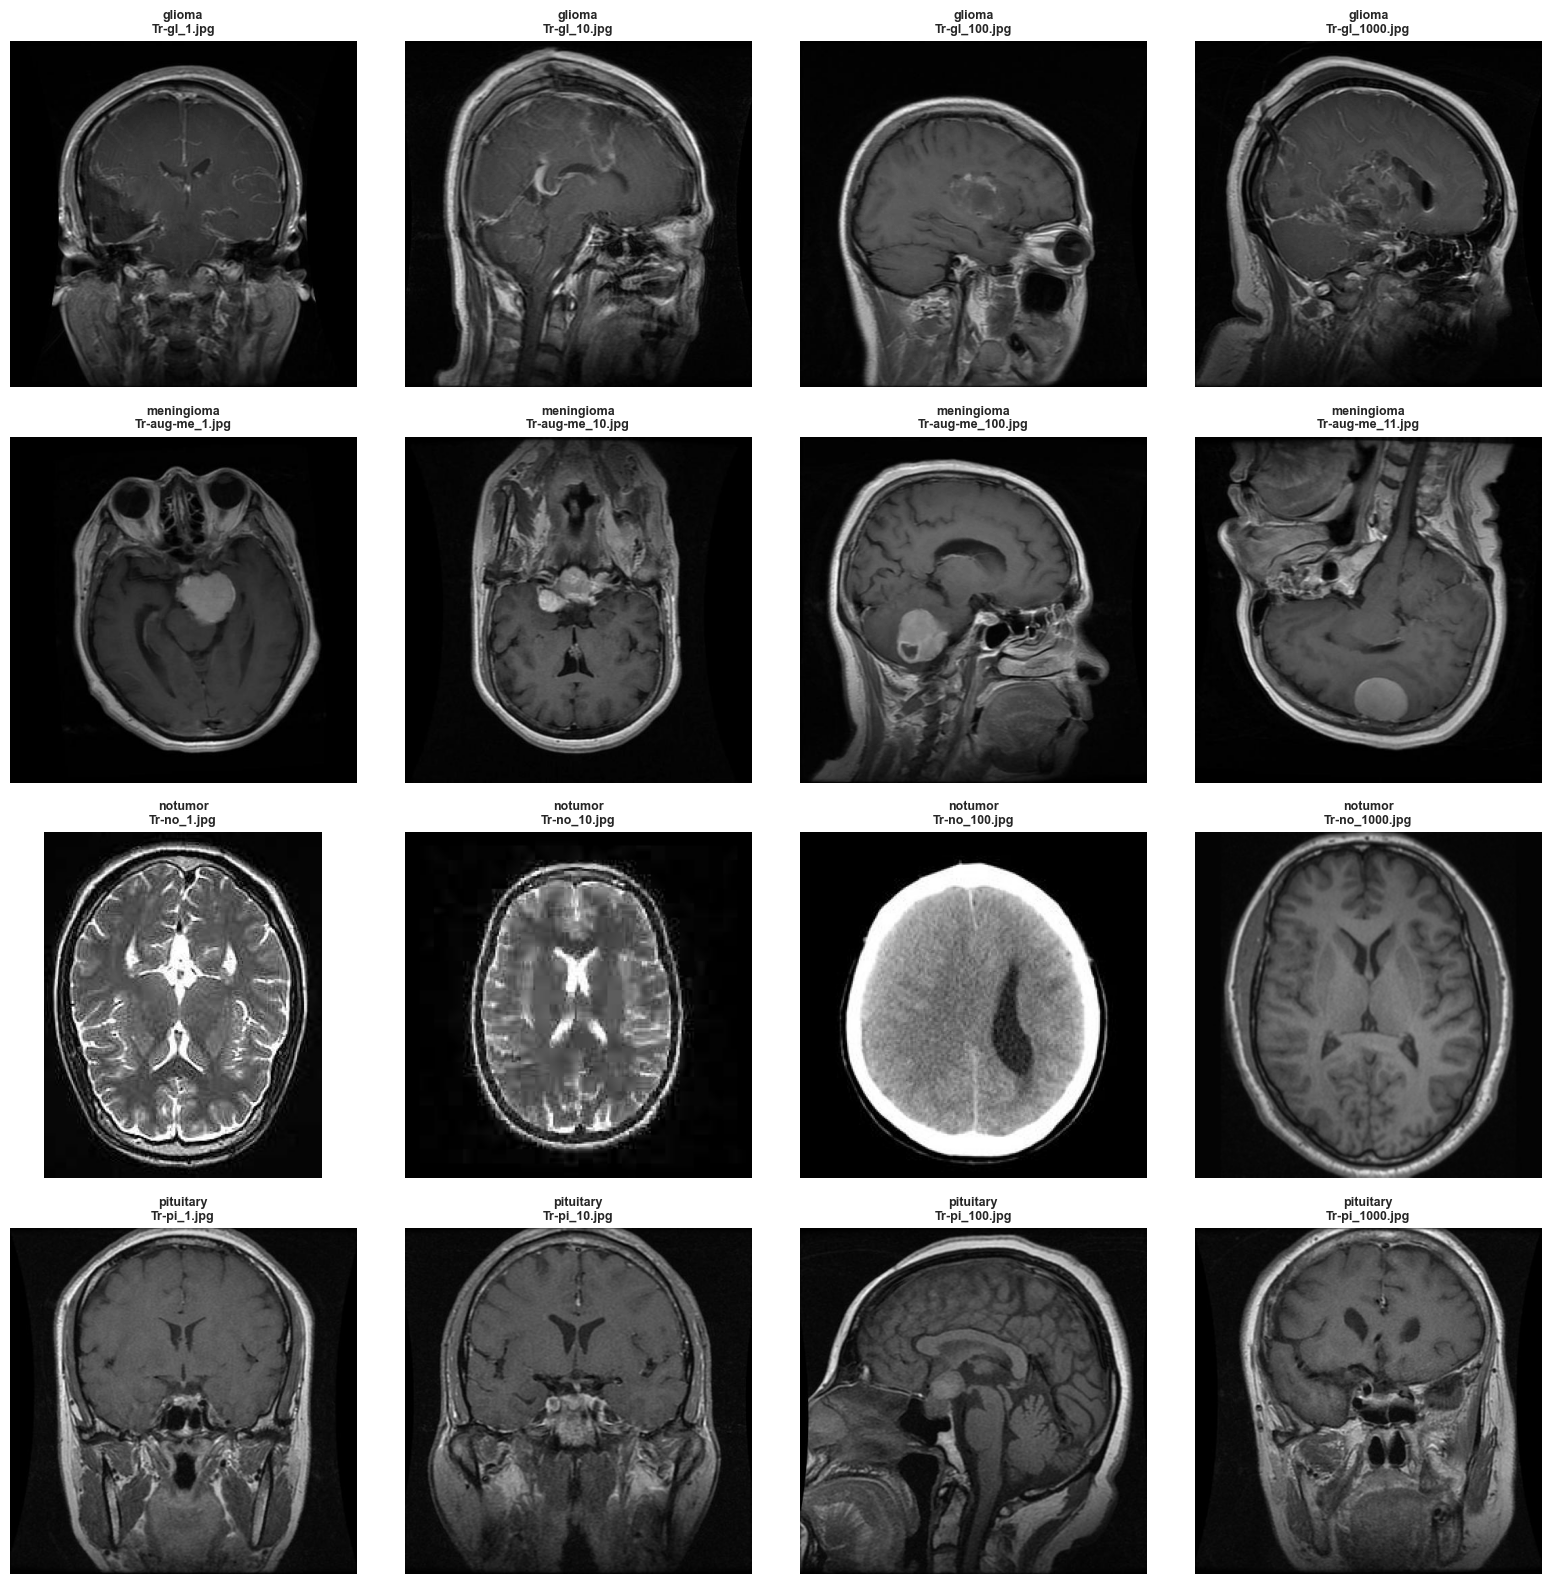

In [14]:
def show_samples(split_root: Path, class_names: list[str], samples_per_class: int = 4) -> None:
    fig, axes = plt.subplots(len(class_names), samples_per_class, figsize=(4 * samples_per_class, 4 * len(class_names)))
    if len(class_names) == 1:
        axes = np.array([axes])
    for row_index, class_name in enumerate(class_names):
        class_files = [p for p in sorted((split_root / class_name).rglob('*')) if p.suffix.lower() in IMAGE_EXTENSIONS]
        chosen = class_files[:samples_per_class]
        for col_index in range(samples_per_class):
            ax = axes[row_index, col_index]
            ax.axis('off')
            if col_index < len(chosen):
                with Image.open(chosen[col_index]) as image:
                    ax.imshow(image, cmap='gray')
                ax.set_title(f'{class_name}\n{chosen[col_index].name}', fontsize=9)
            else:
                ax.set_visible(False)
    plt.tight_layout()
    plt.show()
show_samples(TRAIN_DIR, CLASSES, samples_per_class=4)

## Preprocessing Pipeline

Raw Images

↓

Convert everything to RGB

↓

Resize to 224 × 224

↓

Normalize pixel values

↓

Augmentation

↓

CNN

### Target Folder Structure

- `data/raw/`
  - `Training/`
  - `Testing/`
- `data/processed/`
  - `Training/`
  - `Testing/`
- `data/augmented/`
  - optional

This keeps the original images untouched in `data/raw/`, stores model-ready images in `data/processed/`, and keeps augmented copies separate when needed.
